In [1]:
from google.colab import files
uploaded = files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mahmoudreda55/satellite-image-classification

Saving kaggle.json to kaggle.json
 23% 5.00M/21.8M [00:00<00:00, 44.9MB/s]
100% 21.8M/21.8M [00:00<00:00, 110MB/s] 


In [2]:
!unzip /content/satellite-image-classification.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/data/cloudy/train_23566.jpg  
  inflating: /content/data/data/cloudy/train_23598.jpg  
  inflating: /content/data/data/cloudy/train_23608.jpg  
  inflating: /content/data/data/cloudy/train_23634.jpg  
  inflating: /content/data/data/cloudy/train_23636.jpg  
  inflating: /content/data/data/cloudy/train_23646.jpg  
  inflating: /content/data/data/cloudy/train_2366.jpg  
  inflating: /content/data/data/cloudy/train_23664.jpg  
  inflating: /content/data/data/cloudy/train_23706.jpg  
  inflating: /content/data/data/cloudy/train_2380.jpg  
  inflating: /content/data/data/cloudy/train_23805.jpg  
  inflating: /content/data/data/cloudy/train_23806.jpg  
  inflating: /content/data/data/cloudy/train_23826.jpg  
  inflating: /content/data/data/cloudy/train_23843.jpg  
  inflating: /content/data/data/cloudy/train_23877.jpg  
  inflating: /content/data/data/cloudy/train_23884.jpg  
  inflating: /content/data/data/cloudy/

In [3]:
train_set = '/content/data/data'

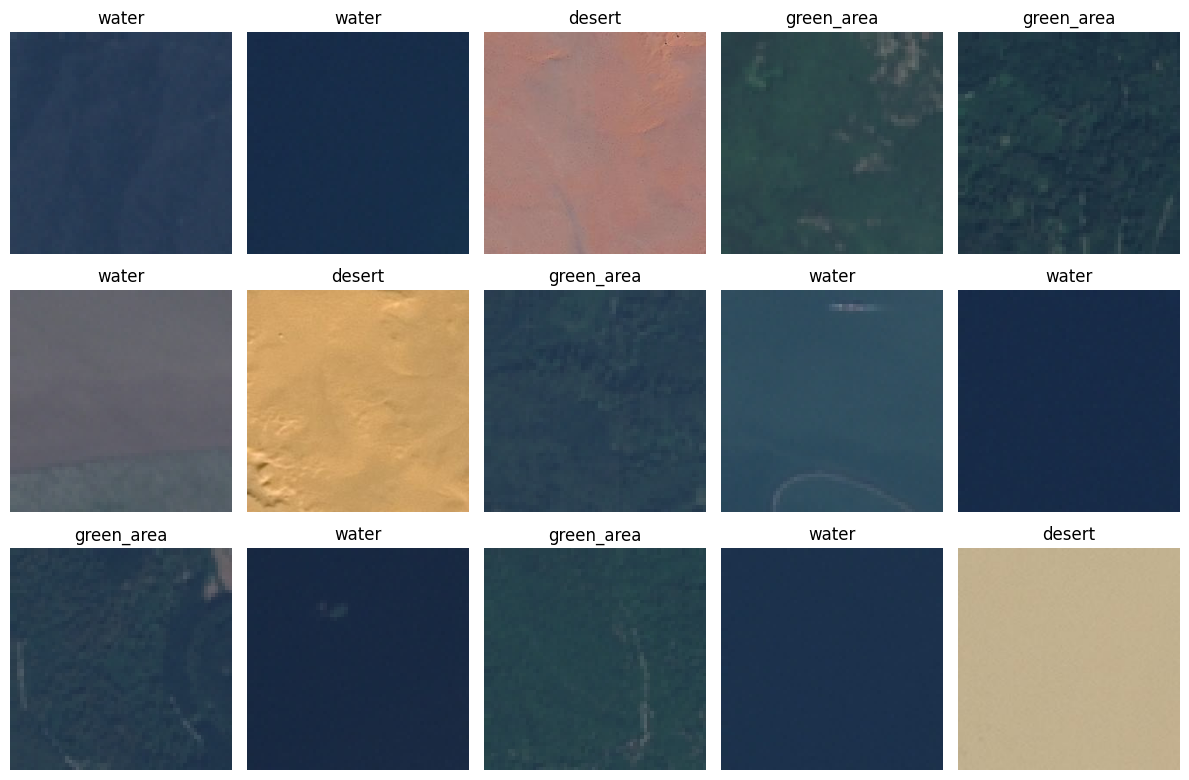

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# Specify the path to your image directory
image_dir = train_set

# Retrieve all image paths recursively from the directory
image_paths = glob.glob(image_dir + '/**/*.jpg', recursive=True)

# Select a subset of images to display
num_images = 15
selected_images = np.random.choice(image_paths, num_images, replace=False)

# Create a grid plot to display the images
rows = 3  # Number of rows in the grid
cols = 5  # Number of columns in the grid
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))

# Iterate over the selected images and display them on the grid
for i, image_path in enumerate(selected_images):
    row = i // cols
    col = i % cols
    img = plt.imread(image_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')

    # Extract the subfolder name from the image path
    subfolder = os.path.basename(os.path.dirname(image_path))

    # Set the subfolder name as the subplot title
    axes[row, col].set_title(subfolder)

# Adjust the spacing between subplots and display the plot
plt.tight_layout()
plt.show()


In [6]:
from keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from keras.applications.mobilenet import MobileNet ,preprocess_input

datagen = ImageDataGenerator(
        rescale = 1./255,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split = 0.2)

train_data = datagen.flow_from_directory(
    train_set,
    target_size = (128,128),
    batch_size =16,
    class_mode = 'categorical',
    subset = 'training')

val_data = datagen.flow_from_directory(
    train_set,
    target_size = (128,128),
    batch_size =16,
    class_mode='categorical',
    subset = 'validation')

Found 4505 images belonging to 4 classes.
Found 1126 images belonging to 4 classes.


In [7]:
print(train_data.class_indices)
print(val_data.class_indices)

{'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}
{'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}


In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models

def residual_block(x, filters, kernel_size=3, stride=1):
    # Shortcut
    shortcut = x

    # First convolution
    x = layers.Conv2D(filters, kernel_size=kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Second convolution
    x = layers.Conv2D(filters, kernel_size=kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Shortcut connection
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

def CNN(input_shape=(128, 128, 3), num_classes=4, extra_layers=2):
    inputs = tf.keras.Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Residual blocks
    num_blocks_list = [3, 4, 6, 3]  # This is for ResNet-50, adjust for other versions
    for stage in range(4):
        for block in range(num_blocks_list[stage]):
            stride = 2 if stage > 0 and block == 0 else 1
            x = residual_block(x, filters=64 * (2**stage), stride=stride)

    # Extra layers for fine feature extraction
    for _ in range(extra_layers):
        x = layers.Conv2D(256, kernel_size=3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Fully connected layer
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs, outputs, name='resnet_with_extra_layers')
    return model

# Example usage:
model = CNN()
model.summary()


Model: "resnet_with_extra_layers"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d_117 (Conv2D)         (None, 64, 64, 64)           9472      ['input_4[0][0]']             
                                                                                                  
 batch_normalization_117 (B  (None, 64, 64, 64)           256       ['conv2d_117[0][0]']          
 atchNormalization)                                                                               
                                                                                                  
 activation_108 (Activation  (None, 64, 64, 64)           0         ['batch

In [45]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',  # Adjust the loss function based on your task
                  metrics=['accuracy'])

In [46]:
history = model.fit(train_data, epochs= 10, validation_data=val_data, workers=8, use_multiprocessing=True, batch_size = 64)

Epoch 1/10
282/282 [==============================] - 72s 168ms/step - loss: 0.7430 - accuracy: 0.6511 - val_loss: 0.9394 - val_accuracy: 0.4991
Epoch 2/10
282/282 [==============================] - 47s 157ms/step - loss: 0.5641 - accuracy: 0.7358 - val_loss: 1.1741 - val_accuracy: 0.6385
Epoch 3/10
282/282 [==============================] - 48s 161ms/step - loss: 0.4755 - accuracy: 0.8009 - val_loss: 0.3496 - val_accuracy: 0.8810
Epoch 4/10
282/282 [==============================] - 47s 160ms/step - loss: 0.4401 - accuracy: 0.8235 - val_loss: 3.6522 - val_accuracy: 0.5071
Epoch 5/10
282/282 [==============================] - 47s 159ms/step - loss: 0.3824 - accuracy: 0.8544 - val_loss: 0.7656 - val_accuracy: 0.6536
Epoch 6/10
282/282 [==============================] - 51s 175ms/step - loss: 0.3923 - accuracy: 0.8426 - val_loss: 0.7317 - val_accuracy: 0.7327
Epoch 7/10
282/282 [==============================] - 46s 158ms/step - loss: 0.3634 - accuracy: 0.8644 - val_loss: 1.0676 - val_ac

In [34]:
model.evaluate(val_data)

71/71 [==============================] - 6s 81ms/step - loss: 0.4983 - accuracy: 0.8943


[0.49828040599823, 0.8943161368370056]

In [47]:
history = model.fit(val_data,epochs=10)

Epoch 1/10
71/71 [==============================] - 9s 126ms/step - loss: 0.3083 - accuracy: 0.8952
Epoch 2/10
71/71 [==============================] - 7s 93ms/step - loss: 0.2872 - accuracy: 0.8943
Epoch 3/10
71/71 [==============================] - 9s 124ms/step - loss: 0.2534 - accuracy: 0.9076
Epoch 4/10
71/71 [==============================] - 7s 94ms/step - loss: 0.3272 - accuracy: 0.8819
Epoch 5/10
71/71 [==============================] - 9s 125ms/step - loss: 0.2591 - accuracy: 0.9085
Epoch 6/10
71/71 [==============================] - 7s 92ms/step - loss: 0.2754 - accuracy: 0.8952
Epoch 7/10
71/71 [==============================] - 9s 126ms/step - loss: 0.2547 - accuracy: 0.9174
Epoch 8/10
71/71 [==============================] - 7s 93ms/step - loss: 0.2435 - accuracy: 0.9112
Epoch 9/10
71/71 [==============================] - 9s 128ms/step - loss: 0.2576 - accuracy: 0.9112
Epoch 10/10
71/71 [==============================] - 7s 94ms/step - loss: 0.2614 - accuracy: 0.8979


In [20]:
def plot_history(history):
    # Plot training and validation loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

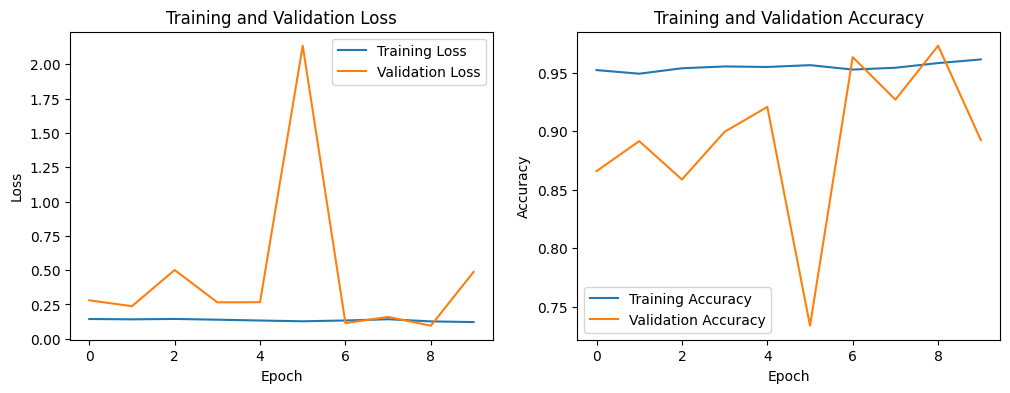

In [21]:
plot_history(history)

71/71 [==============================] - 7s 98ms/step


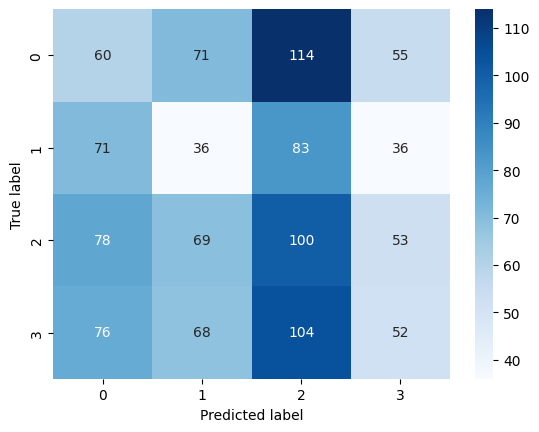

In [22]:
predictions = model.predict(val_data)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = val_data.classes
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [33]:
predictions = model.predict(val_data)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = val_data.classes
from sklearn.metrics import classification_report

report = classification_report(true_labels, predicted_labels, target_names=val_data.class_indices.keys())
print(report)

71/71 [==============================] - 11s 155ms/step
              precision    recall  f1-score   support

      cloudy       0.28      0.26      0.27       300
      desert       0.26      0.27      0.26       226
  green_area       0.25      0.34      0.29       300
       water       0.30      0.20      0.24       300

    accuracy                           0.27      1126
   macro avg       0.27      0.27      0.27      1126
weighted avg       0.27      0.27      0.27      1126



In [28]:
from sklearn.metrics import roc_curve, auc
def plot_roc_curve(model, val_generator, class_index=0):
    # Generate predictions for the validation set
    y_val = val_generator.classes
    y_pred_prob = model.predict(val_generator)

    # Select the true labels and predicted probabilities for the specified class
    y_val_class = np.asarray([1 if label == class_index else 0 for label in y_val])
    y_pred_prob_class = y_pred_prob[:, class_index]

    # Compute ROC curve and AUC for the specified class
    fpr, tpr, _ = roc_curve(y_val_class, y_pred_prob_class)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()


71/71 [==============================] - 7s 101ms/step


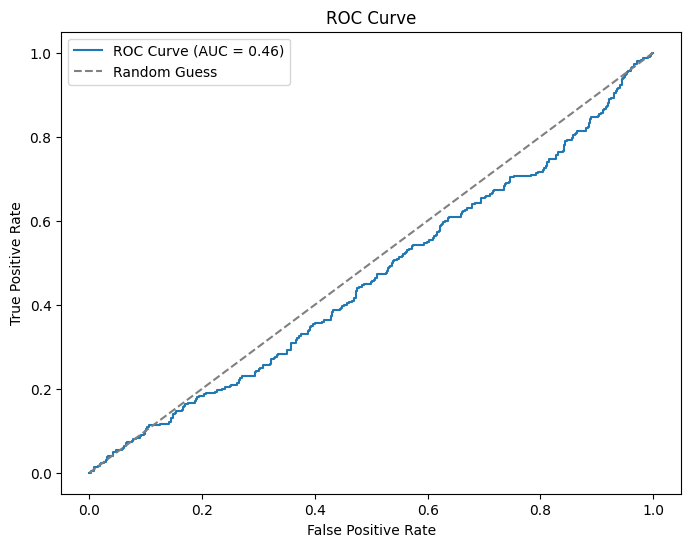

In [32]:
plot_roc_curve(model,val_data,class_index=3)